<a href="https://colab.research.google.com/github/Tshiamo-SE-DS/PyTorch/blob/main/Pre_trained_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

The goal is to fine tune a pre-trained model. The steps are almost similar to Image classification. We will Do another Image Classification process but using a pre-trained model(A model that has been already trained on several tasks). We will be slightling modifying the final layer of the particular model, so it saves and uses its initial knowledge in order to solve our current problem. We will not be building a model from scratch. The process is initially called Transfer Learning, where we transfer the knowledge of our dataset into that particular model.


In [1]:
!pip install opendatasets --quiet
import opendatasets as od
od.download("https://www.kaggle.com/datasets/marquis03/bean-leaf-lesions-classification")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: Tshiamo's FIT
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/marquis03/bean-leaf-lesions-classification


100%|██████████| 155M/155M [00:00<00:00, 1.17GB/s]

In [2]:
import torch
from torch import nn
from torch.optim import Adam
from torch.utils.data import DataLoader, Dataset
from torchvision.transforms import transforms
from torchvision import models
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import pandas as pd
import os

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


## Data Path Reading...

In [3]:
train_df = pd.read_csv("/content/bean-leaf-lesions-classification/train.csv")
val_df = pd.read_csv("/content/bean-leaf-lesions-classification/val.csv")

train_df["image:FILE"] = "/content/bean-leaf-lesions-classification/" + train_df["image:FILE"]
val_df["image:FILE"] = "/content/bean-leaf-lesions-classification/" + val_df["image:FILE"]

"""
data_df = pd.concat([train_df, val_df], ignore_index=True)
data_df["image:FILE"] = "/content/bean-leaf-lesions-classification/" + data_df["image:FILE"]

print("Data shape is: ", data_df.shape)
print()
data_df.head()
"""

train_df.head()

,image:FILE,category
0,/content/bean-leaf-lesions-classification/trai...,0
1,/content/bean-leaf-lesions-classification/trai...,0
2,/content/bean-leaf-lesions-classification/trai...,0
3,/content/bean-leaf-lesions-classification/trai...,0
4,/content/bean-leaf-lesions-classification/trai...,0


In [4]:
train_df["category"].unique()

array([0, 1, 2])

In [5]:
print(train_df.shape)
print(val_df.shape)

(1034, 2)
(133, 2)


In [6]:
print(train_df["category"].value_counts())
#print(val_df["category"].value_counts())

category
2    348
1    345
0    341
Name: count, dtype: int64


# Splitting the Data.

We are spliting the dataset into training and testing. We will be using it differently by reading the image paths from the dataframe, we have to split the dataframe directly and then read the images. This will be done by getting a random sample of 70% from our data. We will then create a new variable of test dataset which we will drop from it the 70% of the train, meaning 30% of the data is the rest if the data.



*   Training: 70%
*   Testing: 30%



In [7]:
#train = data_df.sample(frac = 0.7, random_state = 7) #Create training of 70 % of the data
#test = data_df.drop(train.index) # Create testing by removing the 70% of the train data which will result in 30%

In [8]:
label_encoder = LabelEncoder() #encode the string class to numeric

transform = transforms.Compose([
    transforms.Resize((128,128)),#One size for all images
    transforms.ToTensor(),#Conver images to pytorch tensors
    transforms.ConvertImageDtype(torch.float)
]) #Transform all images into clear format (preprocess all images to same properties)

# The Custom Dataset Class.
The class inherits from the main Dataset class from PyTorch, then we overwrite some of the existing functions in that class. We need to convert our dataset to PyTorch Dataset object as it will be more efficient during training. First we define our class that will be taking the main Dataset class with the concept of inheritance

In the constructor function __init__ we are declaring and our dataframe which will have image_path and the labels. Then we are creating our own image preprocessing object which is transform. For our labels, we are declaring our labels with the label_encoder we declared before. Meaning we will convert our labels changing them from string to numeric classes using fit_tranform. We didn't read each image inside the constructor as reading images here will be so time consuming. However, we are reading each image, applying the preprocessing and returning it in the __getitem__ to read this specific image with its corresponding encoded label by their index and returns them.

In [9]:
class CustomImageDataset(Dataset):
  def __init__(self, dataframe, transform):
    self.dataframe = dataframe
    self.transform = transform
    self.labels = torch.tensor(dataframe["category"]).to(device)

  def __len__(self):
    return self.dataframe.shape[0]

  def __getitem__(self, idx):
    img_path = self.dataframe.iloc[idx, 0]
    label = self.labels[idx]
    image = Image.open(img_path).convert('RGB')
    if self.transform:
      image = (self.transform(image)/255.0).to(device)

    return image, label

# Creation of Dataset Objects.

In [10]:
"""
Here we create 2 data objects for training and testing. The data objects will have the dataframes along with the transform object created earlier on.
To ensure that all images are processed as they are, we will us the same transform object.
"""
train_dataset = CustomImageDataset(dataframe = train_df, transform=transform)
val_dataset = CustomImageDataset(dataframe = val_df, transform=transform)

# Image Visualization using matplotlib package.

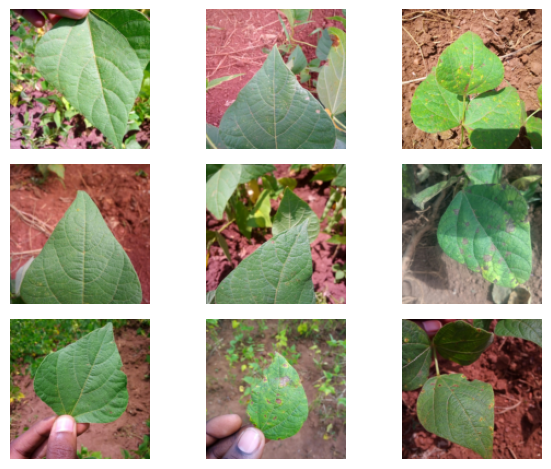

In [11]:
n_rows = 3
n_cols = 3

f, axarr = plt.subplots(n_rows, n_cols)

for row in range(n_rows):
  for col in range(n_cols):
    image = train_dataset[np.random.randint(0, train_dataset.__len__())][0].cpu()
    axarr[row, col].imshow((image*255.0).squeeze().permute(1,2,0))
    axarr[row, col].axis("off")

plt.tight_layout()
plt.show()

#Hyperparameters.
Here we are setting the training hyperparameters by defininf some variables which is the batch size, the number of training epochs and the learning rate.

In [12]:
LR = 1e-3
BATCH_SIZE = 4
EPOCHS = 15

In [13]:
#We create the train loader so we can do the training with batches.
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=True)

In [15]:
# GoogLenet is a pre-trained model we will use. PyTorch has various classification models, with or without pre-trained weights.
googlenet_model = models.googlenet(weights = 'DEFAULT')

In [16]:
"""
The model has trained weights already. We are starting to teach the model from these trained weights. The model already has some
knowledge, so the learning part will not take much time and will require less data. Basically we are telling the model to allow
the parameters/weights to learn again. The difference in this case is that, instead of starting from random weights, its starting
from weights that already has some knowledge, but not the best.
"""
for param in googlenet_model.parameters():
  param.requires_grad = True

In [20]:
#Provides the last linear layer. The model is expecting to predict 1000 classes, but we will change it, we only want 3 classes.
googlenet_model.fc

Linear(in_features=1024, out_features=3, bias=True)

In [21]:
num_classes = len(train_df["category"].unique()) #Here we are checking how many classes we have in category.
num_classes

3

In [22]:
googlenet_model.fc = torch.nn.Linear(googlenet_model.fc.in_features, num_classes)
googlenet_model.fc

Linear(in_features=1024, out_features=3, bias=True)

We will move the model to cuda device because we have our inputs and outputs on the cuda device.

In [23]:
googlenet_model.to(device)

GoogLeNet(
  (conv1): BasicConv2d(
    (conv): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (conv2): BasicConv2d(
    (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (conv3): BasicConv2d(
    (conv): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(192, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (inception3a): Inception(
    (branch1): BasicConv2d(
      (conv): Conv2d(192, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track

In [24]:
#Before we proceed to the training loop, we need to define the loss
loss_fun = nn.CrossEntropyLoss()
optimizer = Adam(googlenet_model.parameters(), lr = LR)


total_loss_train_plot = []
total_acc_train_plot = []

for epoch in range(EPOCHS):
  total_acc_train = 0
  total_loss_train = 0

  for inputs, labels in train_loader:
    optimizer.zero_grad()
    outputs = googlenet_model(inputs)
    train_loss = loss_fun(outputs, labels)
    total_loss_train += train_loss.item()

    train_loss.backward()

    train_acc = (torch.argmax(outputs, axis = 1) == labels).sum().item()
    total_acc_train += train_acc
    optimizer.step()

  total_loss_train_plot.append(round(total_loss_train/1000, 4))
  total_acc_train_plot.append(round(total_acc_train/train_dataset.__len__()* 100, 4))
  print(f"Epoch {epoch+1}/{EPOCHS}, Train Loss: {round(total_loss_train/1000, 4)}, Train Accuracy: {round(total_acc_train/train_dataset.__len__()* 100, 4)} %")

Epoch 1/15, Train Loss: 0.2457, Train Accuracy: 57.4468 %
Epoch 2/15, Train Loss: 0.2042, Train Accuracy: 66.2476 %
Epoch 3/15, Train Loss: 0.1945, Train Accuracy: 68.5687 %
Epoch 4/15, Train Loss: 0.1896, Train Accuracy: 69.5358 %
Epoch 5/15, Train Loss: 0.1736, Train Accuracy: 72.9207 %
Epoch 6/15, Train Loss: 0.1661, Train Accuracy: 73.9845 %
Epoch 7/15, Train Loss: 0.1486, Train Accuracy: 77.2727 %
Epoch 8/15, Train Loss: 0.1336, Train Accuracy: 79.3037 %
Epoch 9/15, Train Loss: 0.1391, Train Accuracy: 79.4971 %
Epoch 10/15, Train Loss: 0.1191, Train Accuracy: 82.5919 %
Epoch 11/15, Train Loss: 0.1146, Train Accuracy: 84.1393 %
Epoch 12/15, Train Loss: 0.0967, Train Accuracy: 86.0735 %
Epoch 13/15, Train Loss: 0.0932, Train Accuracy: 86.3636 %
Epoch 14/15, Train Loss: 0.0935, Train Accuracy: 86.2669 %
Epoch 15/15, Train Loss: 0.0949, Train Accuracy: 86.5571 %


#  Testing

In [25]:
with torch.no_grad():
  total_loss_test = 0
  total_acc_test = 0

  for input, labels in val_loader:
    prediction = googlenet_model(input)

    acc = (torch.argmax(prediction, axis = 1) == labels).sum().item()
    total_acc_test += acc

In [26]:
print(round(total_acc_test/val_dataset.__len__()* 100, 2))

83.46
